# Sklearn GBM Tuning

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from boosting_utils import (
    FEATURES, baseline_models, ensure_output_dir, fit_best_classifier, fit_regressor,
    long_short_backtest, make_boosting_panel, make_intraday_features, model_interpretation,
    score_quantiles, tune_gbm
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_boosting_panel(seed=122)
tuning = tune_gbm(panel)
tuning.to_csv(OUTPUT / 'sklearn_gbm_tuning.csv', index=False)
tuning

,learning_rate,max_depth,cv_roc_auc
1,0.0300,2,0.5311
4,0.0600,2,0.5296
3,0.0600,1,0.5283
0,0.0300,1,0.5273
5,0.0600,3,0.5253
2,0.0300,3,0.5252


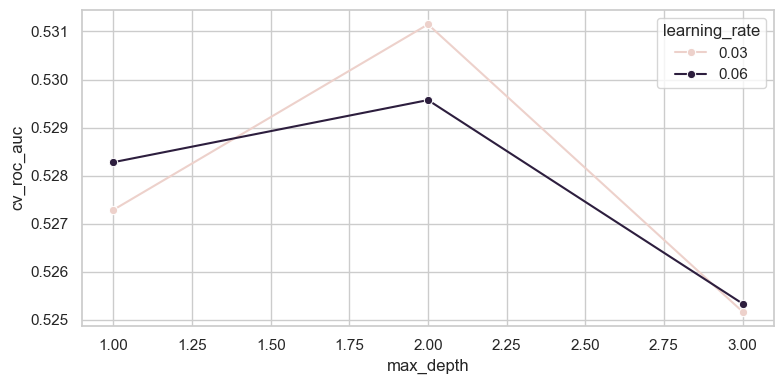

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=tuning, x='max_depth', y='cv_roc_auc', hue='learning_rate', marker='o', ax=ax)
plt.tight_layout()